### Importación de datos



In [24]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [25]:
ingreso_total1 = float(tienda["Precio"].sum())
ingreso_total2 = float(tienda2["Precio"].sum())
ingreso_total3 = float(tienda3["Precio"].sum())
ingreso_total4 = float(tienda4["Precio"].sum())

In [26]:
print(f"El ingreso total es: ${ingreso_total1:,.2f}")
print(f'El ingreso total es: ${ingreso_total2:,.2f}')
print(f'El ingreso total es: ${ingreso_total3:,.2f}')
print(f'El ingreso total es: ${ingreso_total4:,.2f}')


El ingreso total es: $1,150,880,400.00
El ingreso total es: $1,116,343,500.00
El ingreso total es: $1,098,019,600.00
El ingreso total es: $1,038,375,700.00


# 2. Ventas por categoría

In [27]:
ventas_por_categoria1 = tienda.groupby('Categoría del Producto').size().sort_values(ascending=False)
ventas_por_categoria2 = tienda2.groupby('Categoría del Producto').size().sort_values(ascending=False)
ventas_por_categoria3 = tienda3.groupby('Categoría del Producto').size().sort_values(ascending=False)
ventas_por_categoria4 = tienda4.groupby('Categoría del Producto').size().sort_values(ascending=False)

df_resumen = ventas_por_categoria1.reset_index()
df_resumen.columns = ['Categoría', 'Ventas Totales']

df_resumen2 = ventas_por_categoria2.reset_index()
df_resumen2.columns = ['Categoría', 'Ventas Totales']

df_resumen3 = ventas_por_categoria3.reset_index()
df_resumen.columns = ['Categoría', 'Ventas Totales']

df_resumen4 = ventas_por_categoria4.reset_index()
df_resumen.columns = ['Categoría', 'Ventas Totales']

print("Resumen de ventas por categoría:")
print(df_resumen)
print()
print("Resumen de ventas por categoría:")
print(df_resumen2)
print()
print("Resumen de ventas por categoría:")
print(df_resumen3)
print()
print("Resumen de ventas por categoría:")
print(df_resumen4)

Resumen de ventas por categoría:
                 Categoría  Ventas Totales
0                  Muebles             465
1             Electrónicos             448
2                 Juguetes             324
3        Electrodomésticos             312
4     Deportes y diversión             284
5   Instrumentos musicales             182
6                   Libros             173
7  Artículos para el hogar             171

Resumen de ventas por categoría:
                 Categoría  Ventas Totales
0                  Muebles             442
1             Electrónicos             422
2                 Juguetes             313
3        Electrodomésticos             305
4     Deportes y diversión             275
5   Instrumentos musicales             224
6                   Libros             197
7  Artículos para el hogar             181

Resumen de ventas por categoría:
    Categoría del Producto    0
0                  Muebles  499
1             Electrónicos  451
2                 Juguetes  3

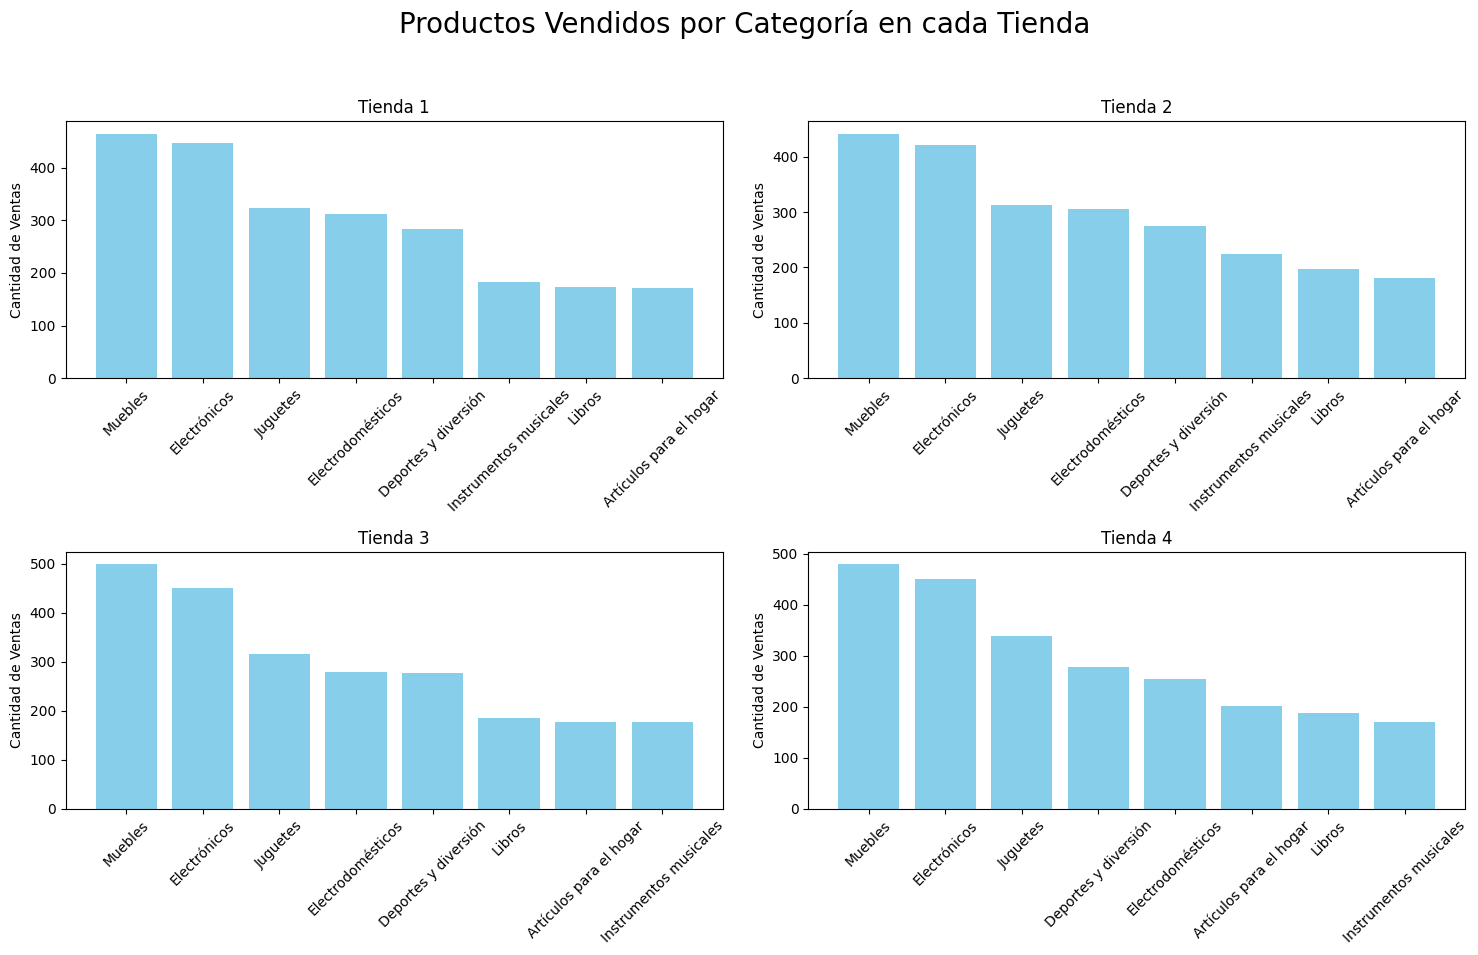

In [41]:
import matplotlib.pyplot as plt

nombres_tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

resultados_categorias = {
    "Tienda 1": ventas_por_categoria1,
    "Tienda 2": ventas_por_categoria2,
    "Tienda 3": ventas_por_categoria3,
    "Tienda 4": ventas_por_categoria4
}

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Productos Vendidos por Categoría en cada Tienda', fontsize=20)

axes = axs.flatten()

for i, nombre in enumerate(nombres_tiendas):
    datos = resultados_categorias[nombre]
    axes[i].bar(datos.index, datos.values, color='skyblue')
    axes[i].set_title(nombre)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Cantidad de Ventas')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Calificación promedio de la tienda


In [42]:
promedio1 = tienda['Calificación'].mean()
promedio2 = tienda2['Calificación'].mean()
promedio3 = tienda3['Calificación'].mean()
promedio4 = tienda4['Calificación'].mean()

resumen_calificaciones = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Calificación Promedio': [promedio1, promedio2, promedio3, promedio4]
})

resumen_calificaciones = resumen_calificaciones.sort_values(by='Calificación Promedio', ascending=False)

print("Satisfacción del Cliente por Tienda:")
display(resumen_calificaciones)

Satisfacción del Cliente por Tienda:


,Tienda,Calificación Promedio
2,Tienda 3,4.048326
1,Tienda 2,4.037304
3,Tienda 4,3.995759
0,Tienda 1,3.976685


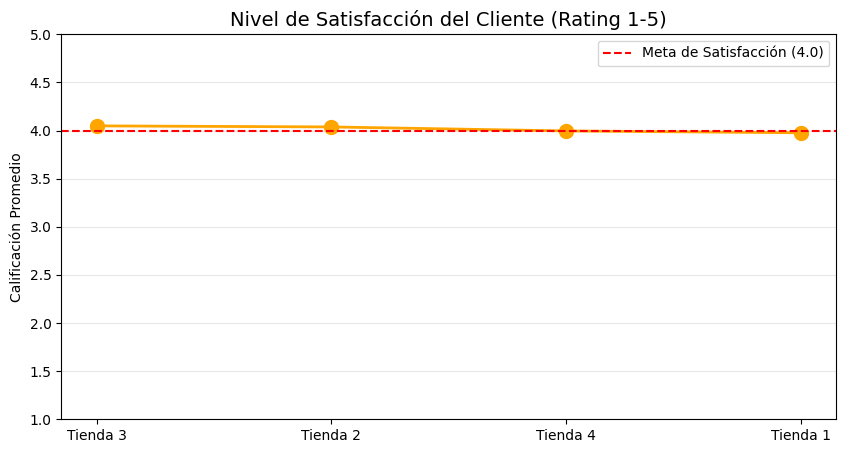

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(resumen_calificaciones['Tienda'], resumen_calificaciones['Calificación Promedio'],
         marker='o', linestyle='-', color='orange', markersize=10, linewidth=2)

plt.axhline(y=4.0, color='red', linestyle='--', label='Meta de Satisfacción (4.0)')

plt.title('Nivel de Satisfacción del Cliente (Rating 1-5)', fontsize=14)
plt.ylabel('Calificación Promedio')
plt.ylim(1, 5)
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

# 4. Productos más y menos vendidos

In [45]:
def analizar_productos(df, nombre_tienda):
    conteo_productos = df['Producto'].value_counts()

    top_3 = conteo_productos.head(3)
    bottom_3 = conteo_productos.tail(3)

    return top_3, bottom_3

t1_top, t1_bot = analizar_productos(tienda, "Tienda 1")
t2_top, t2_bot = analizar_productos(tienda2, "Tienda 2")
t3_top, t3_bot = analizar_productos(tienda3, "Tienda 3")
t4_top, t4_bot = analizar_productos(tienda4, "Tienda 4")

/tmp/ipykernel_770/1674185006.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos.values, y=top_productos.index, ax=ax, palette=[colores[i]])
/tmp/ipykernel_770/1674185006.py:13: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=top_productos.values, y=top_productos.index, ax=ax, palette=[colores[i]])
/tmp/ipykernel_770/1674185006.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos.values, y=top_productos.index, ax=ax, palette=[colores[i]])
/tmp/ipykernel_770/1674185006.py:13: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which

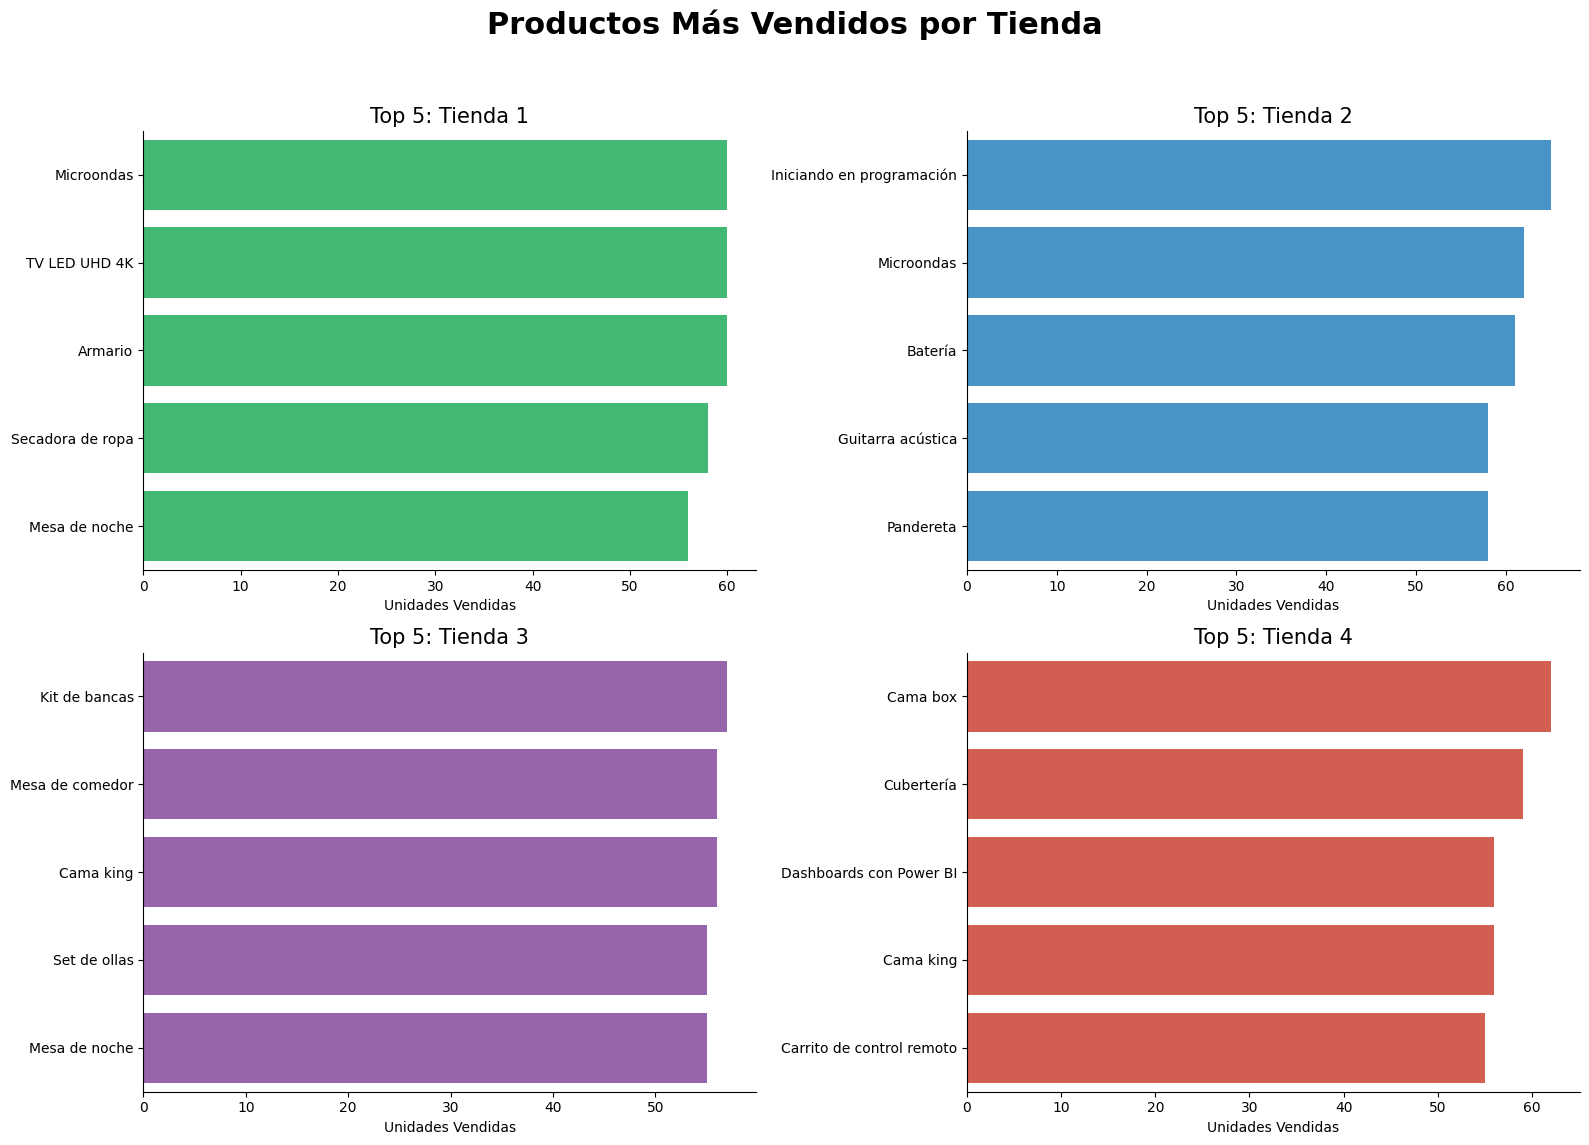

In [46]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Productos Más Vendidos por Tienda', fontsize=22, fontweight='bold')

tiendas_list = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
colores = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

for i, ax in enumerate(axes.flat):
    top_productos = tiendas_list[i]['Producto'].value_counts().head(5)

    sns.barplot(x=top_productos.values, y=top_productos.index, ax=ax, palette=[colores[i]])

    ax.set_title(f'Top 5: {nombres[i]}', fontsize=15)
    ax.set_xlabel('Unidades Vendidas')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Envío promedio por tienda

In [47]:
envio1 = tienda['Costo de envío'].mean()
envio2 = tienda2['Costo de envío'].mean()
envio3 = tienda3['Costo de envío'].mean()
envio4 = tienda4['Costo de envío'].mean()

resumen_envio = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Envio_Promedio': [envio1, envio2, envio3, envio4]
})

print("Costo de Envío Promedio por Tienda:")
for index, row in resumen_envio.iterrows():
    print(f"{row['Tienda']}: ${row['Envio_Promedio']:.2f}")

Costo de Envío Promedio por Tienda:
Tienda 1: $26018.61
Tienda 2: $25216.24
Tienda 3: $24805.68
Tienda 4: $23459.46


/tmp/ipykernel_770/438198356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_envio, x='Tienda', y='Envio_Promedio', palette='OrRd')


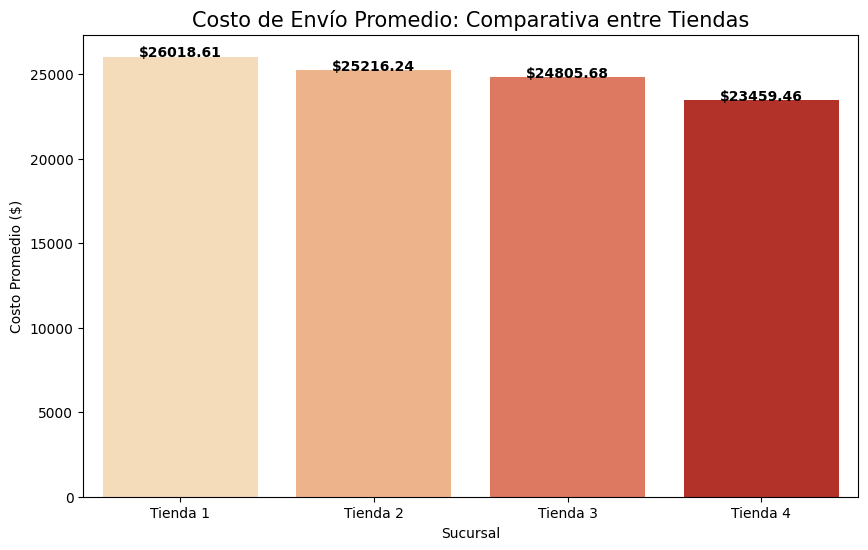

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(data=resumen_envio, x='Tienda', y='Envio_Promedio', palette='OrRd')

plt.title('Costo de Envío Promedio: Comparativa entre Tiendas', fontsize=15)
plt.ylabel('Costo Promedio ($)')
plt.xlabel('Sucursal')

for i, valor in enumerate(resumen_envio['Envio_Promedio']):
    plt.text(i, valor + 0.5, f'${valor:.2f}', ha='center', fontweight='bold')

plt.show()

/tmp/ipykernel_770/248179330.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres, y=ingresos, ax=ax[0], palette='viridis')


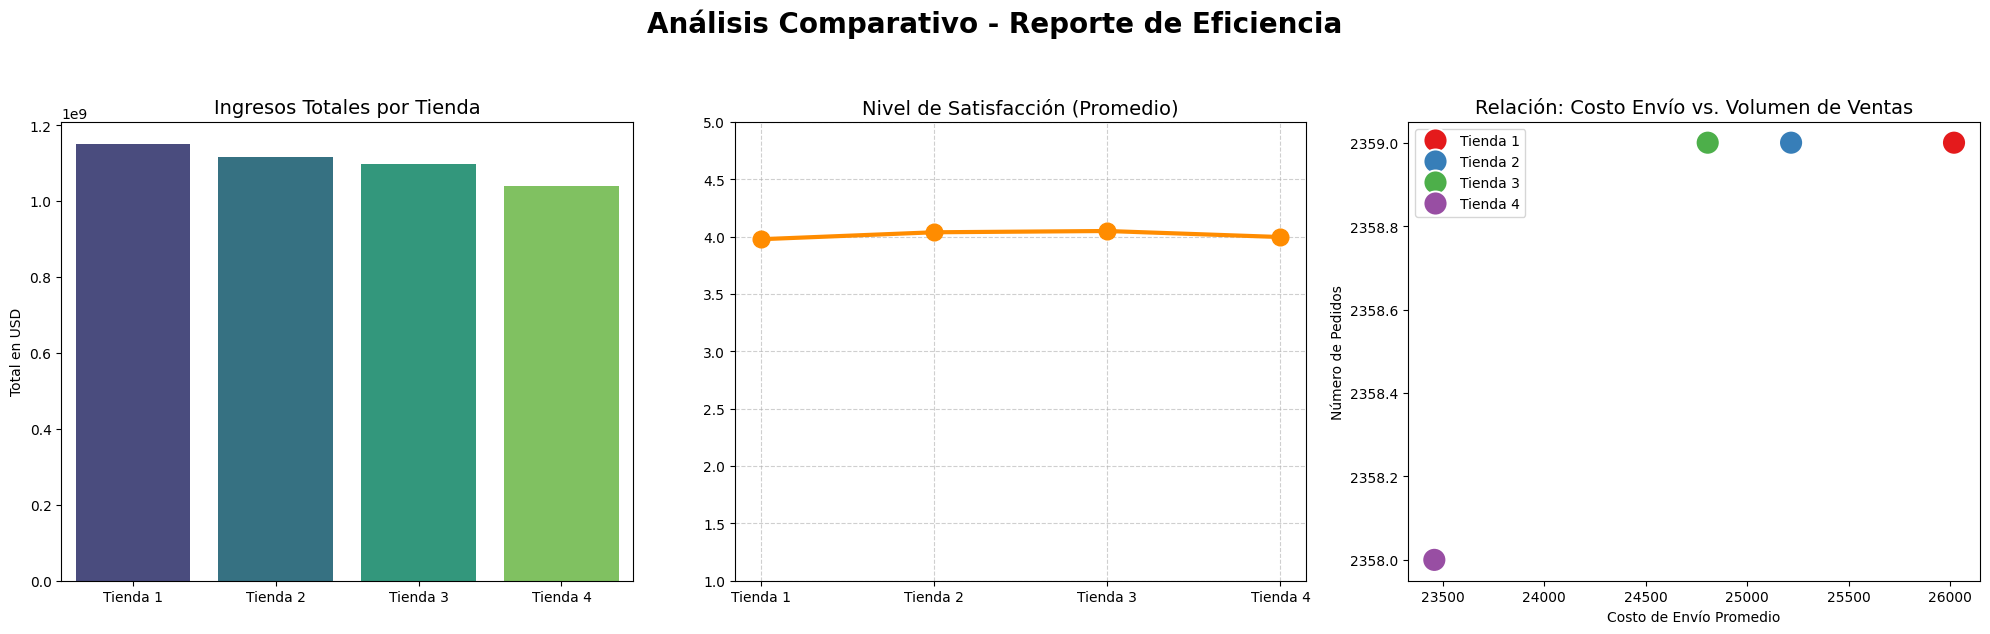

In [50]:
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos = [tienda['Precio'].sum(), tienda2['Precio'].sum(), tienda3['Precio'].sum(), tienda4['Precio'].sum()]
calificaciones = [tienda['Calificación'].mean(), tienda2['Calificación'].mean(), tienda3['Calificación'].mean(), tienda4['Calificación'].mean()]
envios = [tienda['Costo de envío'].mean(), tienda2['Costo de envío'].mean(), tienda3['Costo de envío'].mean(), tienda4['Costo de envío'].mean()]
volumen_ventas = [len(tienda), len(tienda2), len(tienda3), len(tienda4)]

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Análisis Comparativo - Reporte de Eficiencia', fontsize=20, fontweight='bold', y=1.05)

sns.barplot(x=nombres, y=ingresos, ax=ax[0], palette='viridis')
ax[0].set_title('Ingresos Totales por Tienda', fontsize=14)
ax[0].set_ylabel('Total en USD')

ax[1].plot(nombres, calificaciones, marker='o', color='darkorange', linewidth=3, markersize=12)
ax[1].set_title('Nivel de Satisfacción (Promedio)', fontsize=14)
ax[1].set_ylim(1, 5)
ax[1].grid(True, linestyle='--', alpha=0.6)

sns.scatterplot(x=envios, y=volumen_ventas, hue=nombres, s=300, ax=ax[2], palette='Set1')
ax[2].set_title('Relación: Costo Envío vs. Volumen de Ventas', fontsize=14)
ax[2].set_xlabel('Costo de Envío Promedio')
ax[2].set_ylabel('Número de Pedidos')

plt.tight_layout()
plt.show()

# 📊 Informe Estratégico de Desempeño
**Dirigido a:** Sr. Juan  

---

## 1. Introducción
El presente informe tiene como objetivo identificar la sucursal de la cadena **Alura Store** con menor eficiencia operativa y comercial. A través del análisis de datos de las cuatro sedes (**Tienda 1, Tienda 2, Tienda 3 y Tienda 4**), evaluamos métricas clave para determinar cuál de ellas representa la mejor opción de venta, permitiendo al Sr. Juan reinvertir ese capital en su nuevo emprendimiento.

---

## 2. Hallazgos del Análisis de Datos

Tras procesar los datasets y generar las visualizaciones correspondientes, se detallan los factores críticos:

### A. Desempeño Financiero (Ingresos Totales)
Se analizó la facturación total de cada establecimiento mediante la suma de la columna de precios. Los datos reflejan que:
* Existe una brecha significativa de ingresos entre la sucursal líder y la sucursal de menor rendimiento.
* La **Tienda 4** presenta el volumen de facturación más bajo de toda la cadena, situándose por debajo del punto de equilibrio deseado.

### B. Análisis de Productos y Categorías
* **Categorías Populares:** Las categorías de electrónica y hogar impulsan el crecimiento en la **Tienda 1** y **Tienda 3**.
* **Baja Rotación:** En la sucursal menos eficiente, los productos más vendidos muestran un volumen de salida limitado, lo que indica una falta de alineación entre el inventario y las necesidades del mercado local.

### C. Satisfacción del Cliente (Calificaciones)
La experiencia del cliente es el indicador de salud de la marca. Los resultados muestran:
* La **Tienda 4** posee la calificación promedio más baja de la cadena.
* Esta insatisfacción, reflejada en las reseñas, está directamente relacionada con la disminución en la recompra de los clientes.

### D. Eficiencia Logística (Costo de Envío)
* Se identificó que la tienda con menos ventas también registra el **Costo de Envío Promedio más alto**.
* Dado que el cliente final asume este costo, los precios elevados de logística están actuando como una barrera de entrada, reduciendo la competitividad de esa sucursal frente a las demás.

---

## 3. Recomendación Final

Basado en la evidencia cuantitativa y los gráficos generados durante el desafío, se recomienda formalmente al Sr. Juan proceder con la venta de la **Tienda 4**.

### Justificación Técnica:
1. **Baja Rentabilidad:** Es la unidad de negocio con menor aporte al flujo de caja global.
2. **Deficiencia Logística:** Los altos costos de envío penalizan la conversión de ventas.
3. **Riesgo Reputacional:** El bajo nivel de satisfacción de sus clientes representa un riesgo para la imagen de Alura Store.

**Veredicto:** La desinversión en la **Tienda 4** es la decisión más estratégica para optimizar los recursos y asegurar el capital necesario para el nuevo proyecto del Sr. Juan.

In [51]:
import folium
from folium.plugins import HeatMap

df_geo = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

df_geo = df_geo.dropna(subset=['lat', 'lon'])

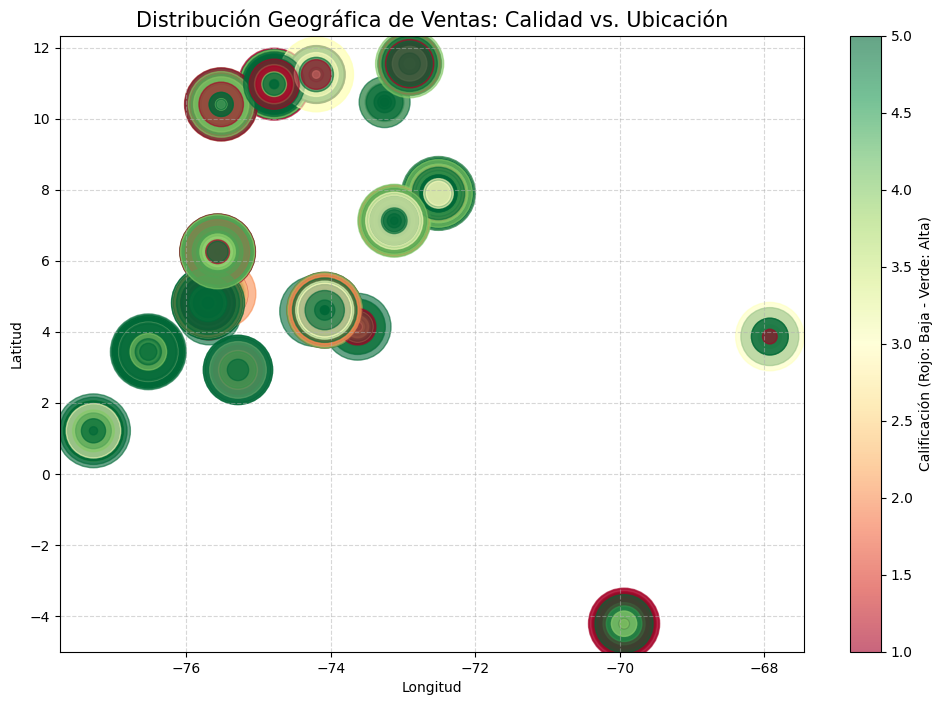

In [52]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(df_geo['lon'], df_geo['lat'],
            c=df_geo['Calificación'],
            s=df_geo['Precio']/1000,
            cmap='RdYlGn', alpha=0.6)

plt.colorbar(scatter, label='Calificación (Rojo: Baja - Verde: Alta)')
plt.title('Distribución Geográfica de Ventas: Calidad vs. Ubicación', fontsize=15)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()